In [37]:
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
# Cargar los datos del excel (csv)
tabla = pd.read_csv('Mall_Customers.csv')

In [39]:
# Cambiar nombres para entender mejor
tabla = tabla.rename(columns={
    'CustomerID': 'id',
    'Genre': 'genero',
    'Age': 'edad',
    'Annual Income (k$)': 'ingresos',
    'Spending Score (1-100)': 'puntaje'
})

In [40]:
# Ver las primeras filas
tabla.head()

,id,genero,edad,ingresos,puntaje
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [41]:
# Ver si hay celdas vacias
print(tabla.isnull().sum())

id          0
genero      0
edad        0
ingresos    0
puntaje     0
dtype: int64


In [42]:
# Ver los promedios de todo
tabla.describe()

,id,edad,ingresos,puntaje
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [43]:
import seaborn as sns # Importar acá porque me olvidé arriba

Text(0.5, 1.0, 'Distribución de edades')

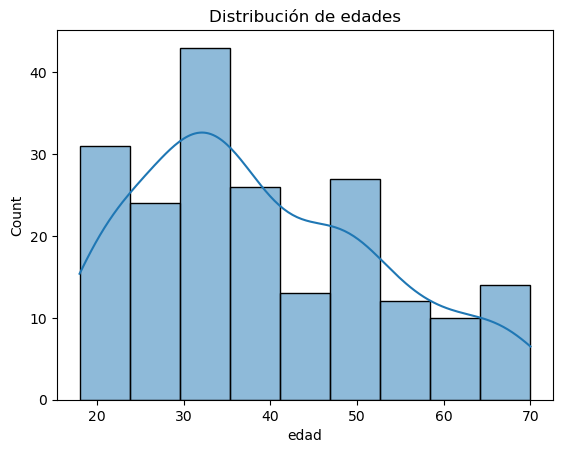

In [44]:
# Hacer un histograma de la edad
sns.histplot(tabla['edad'], kde=True)
plt.title('Distribución de edades')

In [45]:
import statsmodels.api as sm

In [46]:
# Elegir las columnas para la cuenta
X = tabla[['edad', 'ingresos']]
y = tabla['puntaje']

In [47]:
# Agregar la constante y hacer la regresion
X = sm.add_constant(X)
resultado = sm.OLS(y, X).fit()

In [48]:
# Ver que dio la regresion
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                puntaje   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     11.82
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.42e-05
Time:                        00:39:27   Log-Likelihood:                -922.21
No. Observations:                 200   AIC:                             1850.
Df Residuals:                     197   BIC:                             1860.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         73.3479      6.553     11.193      0.0

In [49]:
from scipy import stats

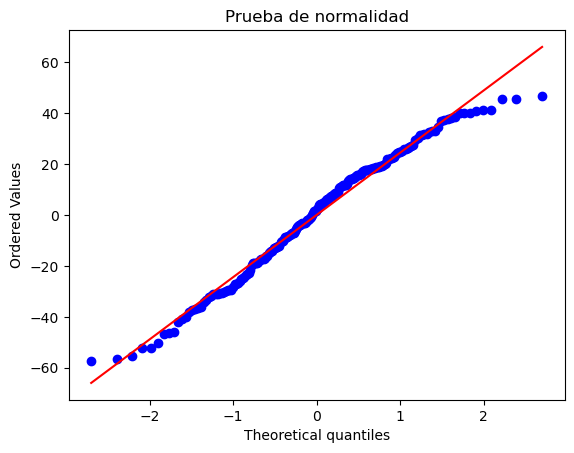

In [50]:
# Graficar para ver si los errores estan bien
stats.probplot(resultado.resid, dist="norm", plot=plt)
plt.title('Prueba de normalidad')
plt.show()

In [51]:
# Calcular la matriz de correlacion para ver relaciones
matriz = tabla[['edad', 'ingresos', 'puntaje']].corr()

In [52]:
# Calcular la correlación entre las variables numéricas
matriz_corr = tabla[['edad', 'ingresos', 'puntaje']].corr()

Text(0.5, 1.0, 'Matriz de Correlación')

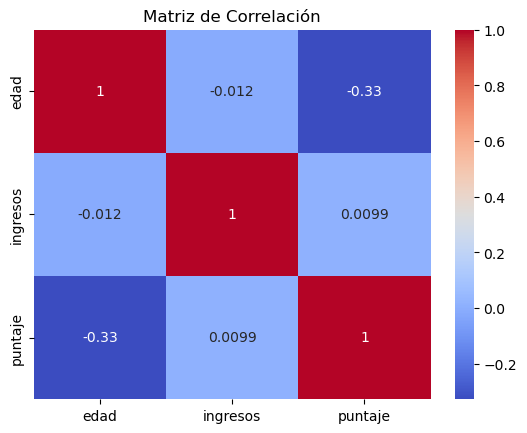

In [53]:
# Graficar el mapa de calor
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')

El modelo de regresión proporciona un R² de 0.109 con lo que la pareja compuesta por edad e ingresos estaría aportando muy poco en cuanto a la explicación del puntaje de gasto de los clientes. Aunque los residuos muestran una distribución aproximadamente normal, el bajo R² sugiere que hay otras variables que intervienen en cómo el consumidor gasta. Por ello, se sugiere que ComercioYA analice otras variables que le permitan afinar el conocimiento del gasto del cliente.